# HMM Regime Shift Portfolio Allocation

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import MarketConfig, asset_returns, download_market_data
from src.features import align_returns_to_features, build_hmm_features, scale_train_test
from src.hmm_model import fit_hmm, label_regimes, predict_regimes, summarize_regimes
from src.backtester import build_benchmarks, run_walk_forward_backtest
from src.metrics import performance_table
from src.plots import plot_drawdowns, plot_equity_curves, plot_regimes_on_price, plot_weights

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.4f}".format

CONFIG = MarketConfig(start="2005-01-01", assets=("SPY", "TLT", "GLD"), proxies=("^VIX",))
TRANSACTION_COST_BPS = 10.0
TRAIN_YEARS = 5

## 2. Data Ingestion

The portfolio universe uses SPY for equities, TLT for long-duration Treasury bonds, and GLD as a safe-haven gold proxy. VIX is used as a market stress proxy for regime detection.

In [2]:
prices = download_market_data(CONFIG)
returns = asset_returns(prices, CONFIG.assets)

display(prices.tail())
display(returns.tail())

Ticker,SPY,TLT,GLD,^VIX
Date,,,,
2026-05-15,739.1700,83.6600,417.2900,18.4300
2026-05-18,738.6500,83.5600,418.4300,17.8200
2026-05-19,733.7300,83.0200,411.5000,18.0600
2026-05-20,741.2500,83.9100,417.4000,17.4400
2026-05-21,742.7200,84.2200,416.9900,16.7600


Ticker,SPY,TLT,GLD
Date,,,
2026-05-15,-0.0120,-0.0148,-0.0232
2026-05-18,-0.0007,-0.0012,0.0027
2026-05-19,-0.0067,-0.0065,-0.0166
2026-05-20,0.0102,0.0107,0.0143
2026-05-21,0.0020,0.0037,-0.0010


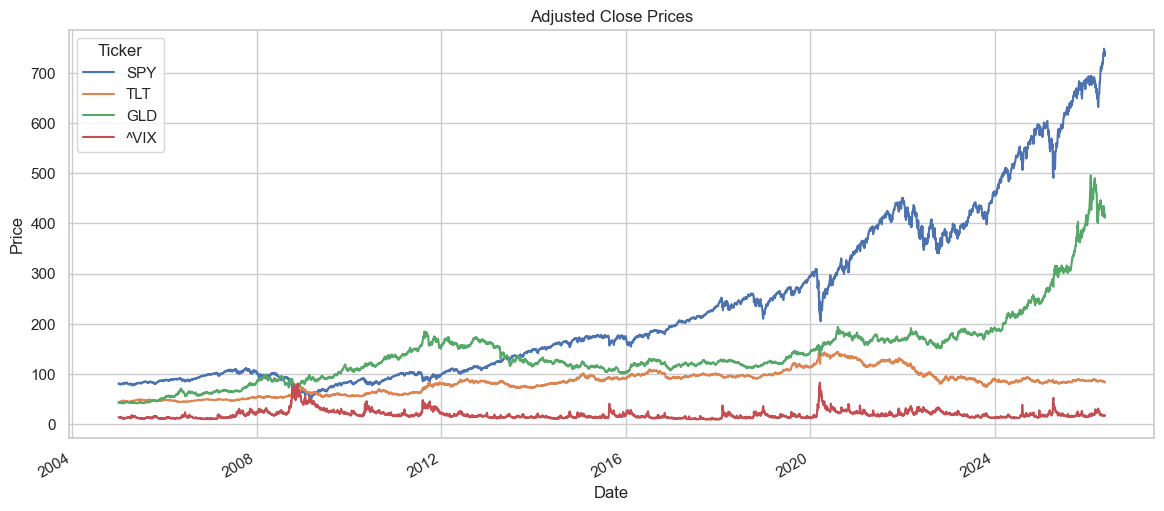

In [3]:
prices.plot(figsize=(14, 6), title="Adjusted Close Prices")
plt.ylabel("Price")
plt.show()

## 3. Feature Engineering

The HMM is trained on backward-looking features only: equity returns, rolling volatility, momentum, bond and gold returns, VIX level, and VIX change.

In [4]:
features = build_hmm_features(prices)
aligned_returns = align_returns_to_features(returns, features)

display(features.tail())
display(features.describe().T)

,equity_return_1d,equity_vol_21d,equity_momentum_63d,bond_return_1d,gold_return_1d,vix_level,vix_change_5d
Date,,,,,,,
2026-05-15,-0.0120,0.0070,0.0872,-0.0148,-0.0232,18.4300,0.0721
2026-05-18,-0.0007,0.0066,0.0847,-0.0012,0.0027,17.8200,-0.0305
2026-05-19,-0.0067,0.0068,0.0720,-0.0065,-0.0166,18.0600,0.0039
2026-05-20,0.0102,0.0068,0.0859,0.0107,0.0143,17.4400,-0.0241
2026-05-21,0.0020,0.0066,0.0802,0.0037,-0.0010,16.7600,-0.0290


,count,mean,std,min,25%,50%,75%,max
equity_return_1d,5317.0000,0.0005,0.0120,-0.1094,-0.0039,0.0007,0.0058,0.1452
equity_vol_21d,5317.0000,0.0099,0.0070,0.0022,0.0059,0.0082,0.0116,0.0595
equity_momentum_63d,5317.0000,0.0287,0.0751,-0.4147,-0.0056,0.0394,0.0726,0.3994
bond_return_1d,5317.0000,0.0002,0.0092,-0.0667,-0.0053,0.0004,0.0055,0.0752
gold_return_1d,5317.0000,0.0005,0.0115,-0.1027,-0.0051,0.0006,0.0064,0.1129
vix_level,5317.0000,19.2331,8.6092,9.1400,13.5500,16.9100,22.2100,82.6900
vix_change_5d,5317.0000,0.0120,0.1662,-0.4667,-0.0806,-0.0092,0.0770,2.1290


## 4. In-Sample Regime Inspection

This section fits an HMM on the full sample only for exploratory regime interpretation. The actual backtest later re-fits the model walk-forward using only past data.

In [5]:
train_scaled, _, scaler = scale_train_test(features, features)
inspection_model = fit_hmm(train_scaled, n_components=3)
inspection_regimes = predict_regimes(inspection_model, train_scaled)
inspection_labels = label_regimes(inspection_regimes, aligned_returns)
inspection_regime_frame = inspection_regimes.to_frame()
inspection_regime_frame["regime_label"] = inspection_regime_frame["regime"].map(inspection_labels)

display(summarize_regimes(inspection_regimes, features, aligned_returns))
display(inspection_regime_frame["regime_label"].value_counts())

,equity_return_1d,equity_vol_21d,equity_momentum_63d,bond_return_1d,gold_return_1d,vix_level,vix_change_5d,SPY_return,TLT_return,GLD_return
regime,,,,,,,,,,
0,-0.0012,0.0242,-0.0986,0.0004,-0.0003,38.0084,0.1152,-0.0012,0.0004,-0.0003
1,0.0004,0.0109,0.0274,0.0001,0.0006,21.2444,0.0082,0.0004,0.0001,0.0006
2,0.0009,0.0061,0.0551,0.0001,0.0005,13.7492,-0.0052,0.0009,0.0001,0.0005


regime_label
bull       2563
neutral    2246
crisis      508
Name: count, dtype: int64

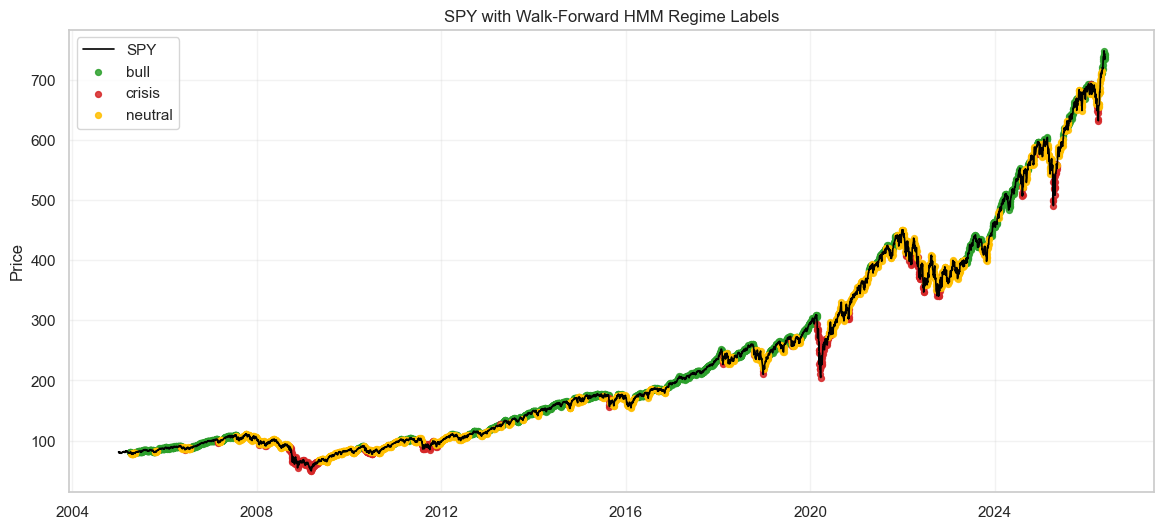

In [6]:
plot_regimes_on_price(prices, inspection_regime_frame, asset="SPY")

### HMM Transition Probabilities

The transition matrix shows the probability of moving from one hidden regime to another on the next trading day.

In [7]:
transition_matrix = pd.DataFrame(
    inspection_model.transmat_,
    index=[f"from_regime_{i}" for i in range(inspection_model.n_components)],
    columns=[f"to_regime_{i}" for i in range(inspection_model.n_components)],
)
display(transition_matrix)

,to_regime_0,to_regime_1,to_regime_2
from_regime_0,0.9286,0.0714,0.0000
from_regime_1,0.0115,0.9634,0.0251
from_regime_2,0.0045,0.0174,0.9781


## 5. Walk-Forward Backtest

At each monthly rebalance date, the HMM is trained only on data available before that date. The current regime is predicted, mapped to a constraint set, and passed to the optimizer. Transaction costs are applied using a 10 bps turnover penalty.

In [8]:
strategy, weights, walk_forward_regimes = run_walk_forward_backtest(
    features=features,
    returns=aligned_returns,
    train_years=TRAIN_YEARS,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    n_components=3,
)

display(strategy.head())
display(weights.head())
display(walk_forward_regimes["regime_label"].value_counts())

C:\Users\HP\anaconda3\envs\quant\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


,strategy_return,regime,regime_label,turnover,transaction_cost,bull_probability,neutral_probability,crisis_probability
date,,,,,,,,
2010-05-03,0.0084,0,neutral,0.7330,0.0007,0.0000,0.9999,0.0001
2010-05-04,-0.0136,0,neutral,0.0000,0.0000,0.0000,0.9999,0.0001
2010-05-05,-0.0028,0,neutral,0.0000,0.0000,0.0000,0.9999,0.0001
2010-05-06,-0.0141,0,neutral,0.0000,0.0000,0.0000,0.9999,0.0001
2010-05-07,-0.0131,0,neutral,0.0000,0.0000,0.0000,0.9999,0.0001


,SPY,TLT,GLD,regime,regime_label,bull_probability,neutral_probability,crisis_probability,turnover
date,,,,,,,,,
2010-04-30,0.6998,0.1999,0.1002,0,neutral,0.0000,0.9999,0.0001,0.7330
2010-05-28,0.4500,0.1001,0.4499,1,crisis,0.0000,0.0101,0.9899,0.6994
2010-06-30,0.6993,0.2003,0.1004,1,neutral,0.0000,0.9980,0.0020,0.6990
2010-07-30,0.6993,0.2004,0.1003,0,neutral,0.0000,1.0000,0.0000,0.0003
2010-08-31,0.6992,0.2004,0.1004,1,neutral,0.0000,0.9999,0.0001,0.0002


regime_label
neutral    94
bull       79
crisis     20
Name: count, dtype: int64

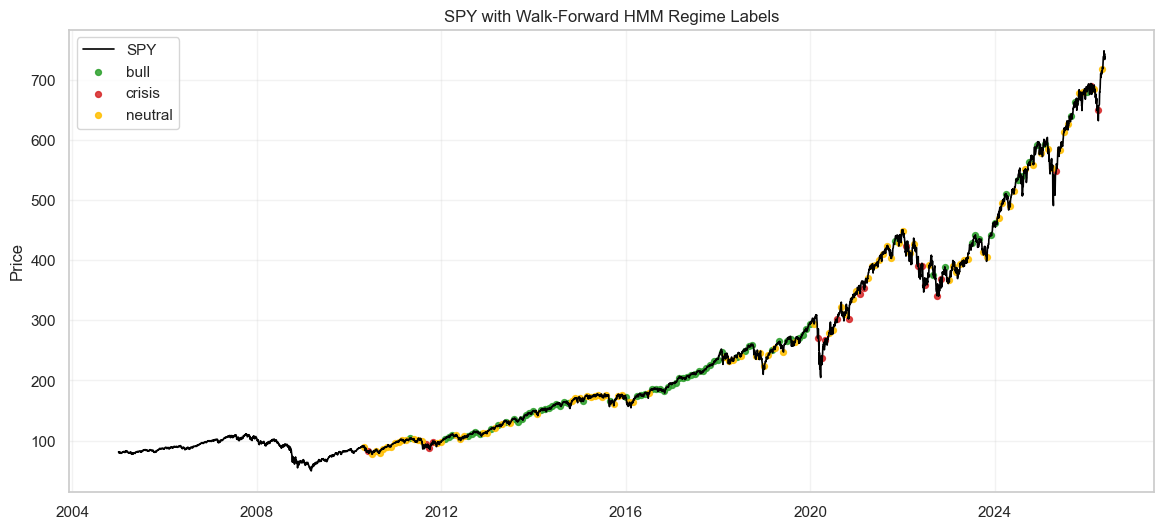

In [16]:
plot_regimes_on_price(prices, walk_forward_regimes, asset="SPY")

## 6. Static Benchmarks

The dynamic strategy is compared against a 60/40 SPY/TLT portfolio and an equal-weight SPY/TLT/GLD portfolio.

,strategy,60_40,equal_weight
date,,,
2026-05-15,-0.0137,-0.0132,-0.0167
2026-05-18,-0.0005,-0.0009,0.0003
2026-05-19,-0.0076,-0.0066,-0.0099
2026-05-20,0.0108,0.0104,0.0118
2026-05-21,0.0020,0.0027,0.0016


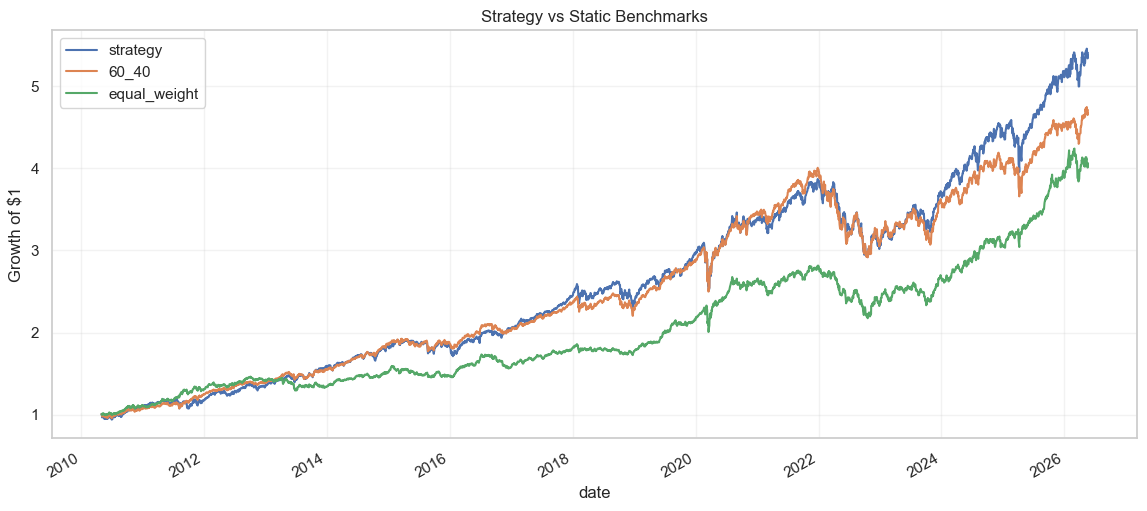

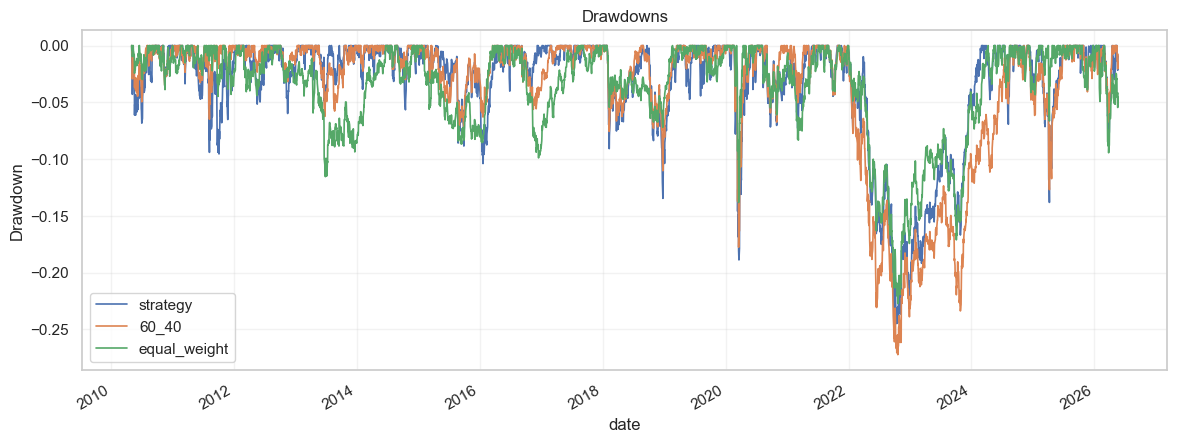

In [10]:
benchmarks = build_benchmarks(aligned_returns, strategy.index)
return_frame = pd.concat(
    [strategy["strategy_return"].rename("strategy"), benchmarks],
    axis=1,
).dropna()

display(return_frame.tail())
plot_equity_curves(return_frame)
plot_drawdowns(return_frame)

## 7. Performance Tear Sheet

In [11]:
tear_sheet = performance_table(return_frame, turnover=strategy["turnover"])
display(tear_sheet.style.format("{:.2%}", subset=["annual_return", "annual_volatility", "max_drawdown", "total_return", "avg_monthly_turnover"]).format("{:.2f}", subset=["sharpe", "sortino", "calmar"]))

,annual_return,annual_volatility,sharpe,sortino,max_drawdown,calmar,total_return,avg_monthly_turnover
strategy,,,,,,,,
strategy,11.24%,11.88%,0.95,1.23,-24.50%,0.46,440.85%,0.88%
60_40,10.21%,10.34%,0.99,1.28,-27.24%,0.37,371.11%,nan%
equal_weight,9.19%,9.34%,0.98,1.34,-22.74%,0.40,306.35%,nan%


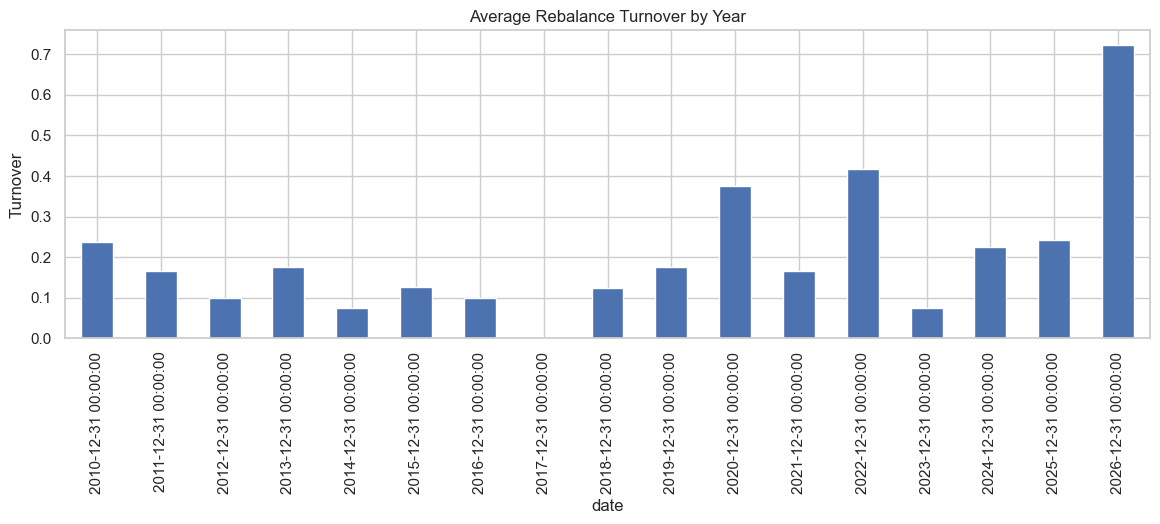

In [12]:
monthly_turnover = weights["turnover"].resample("YE").mean()
monthly_turnover.plot(kind="bar", figsize=(14, 4), title="Average Rebalance Turnover by Year")
plt.ylabel("Turnover")
plt.show()